In [7]:
from __future__ import annotations

from Soccer_Simulation_Helpers import *

import pandas as pd

n_conferences = number of conferences/bubbles
n_strong = number of strong conferences
strong_mean = mean team strength of strong conferences
weak_mean = mean team strength of weak conferences
teams_per_conference = # of teams per conference
k_nonconf = number of nonconference opponents
strength_sampler = strength
balance_across_conferences =
within_sigma = team strength sampler max standard deviation

In [ ]:
for c in range(6):
  results = []
  for s in range(1000):
    if c < 6:
      sampler, baselines = tiered_conference_baselines(
          n_conferences=4, n_strong=0, strong_mean=2, weak_mean=0, within_sigma=1
      )
      strong = 0
      if c == 3:
        sampler, baselines = tiered_conference_baselines(
            n_conferences=4, n_strong=1, strong_mean=2, weak_mean=0, within_sigma=1
        )
        strong = 1

    if c < 5:
      teams, games = build_schedule_with_conferences_mixed_nonconf(
          n_conferences=4,
          teams_per_conference=8,
          k_nonconf=0,
          strength_sampler=sampler,
          balance_across_conferences=True
      )
      k = 0
      if c < 4:
          teams, games = build_schedule_with_conferences_mixed_nonconf(
              n_conferences=4,
              teams_per_conference=8,
              k_nonconf=1,
              strength_sampler=sampler,
              balance_across_conferences=True
          )
          k = 1
          if c < 2:
              teams, games = build_schedule_with_conferences_mixed_nonconf(
                  n_conferences=4,
                  teams_per_conference=8,
                  k_nonconf=4,
                  strength_sampler=sampler,
                  balance_across_conferences=True
              )
              k = 4
    else:
      teams, games = build_schedule_with_conferences_mixed_nonconf(
          n_conferences=4,
          teams_per_conference=8,
          k_nonconf=4,
          strength_sampler=sampler,
          balance_across_conferences=True
      )
      k = 4
    if c < 2:
      teams[0] = Team(tid = 0, conference = 0, strength = 2.5)
      if c < 1:
        teams[1] = Team(tid = 0, conference = 0, strength = 2.5)

    gdf = simulate_results(games=games, teams=teams, stochastic= True)

    npi_df = calculate_npi(gdf)

    strength = [x.strength for x in teams]
    npi = [0 for x in teams]
    wins = [0 for x in teams]
    losses = [0 for x in teams]
    conf = [x.conference for x in teams]

    for index, row in npi_df.iterrows():

        npi[int(row['team'])] = row['npi']

    for index, row in gdf.iterrows():

        if row['home_score'] ==1:
            wins[row['home_team']] += 1
            losses[row['away_team']] += 1
        else:
            wins[row['away_team']] += 1
            losses[row['home_team']] += 1

    npi_calibration_report(strength, npi, wins, losses, conf, topk_list=(2,4,8))
    if c < 2:
      confcol_one = pd.Series(npi[1:8])
      if c < 1:
        confcol_one = pd.Series(npi[2:8])
    else:
      confcol_one = pd.Series(npi[0:8])
    confcol_two = pd.Series(npi[8:15])
    mean_diff = confcol_one.mean() - confcol_two.mean()
    results.append(mean_diff)

  season_one = pd.Series(results)

  print(c)
  print(season_one.mean())

 # print(teams[0].strength, teams[1].strength, k, strong)
 # print(confcol_one)
#season_one = pd.DataFrame(results, index = ["first", "second", "third", "fourth", "fifth", "sixth", "seventh", "eighth", "ninth", "tenth"])

#print(season_one)

In [1]:
results = []
for s in range(1):
  sampler, baselines = tiered_conference_baselines(
      n_conferences=2, n_strong=0, strong_mean=2, weak_mean=0, within_sigma=1
  )

  teams, games = build_schedule_with_conferences_mixed_nonconf(
      n_conferences=2,
      teams_per_conference=8,
      k_nonconf=4,
      strength_sampler=sampler,
      balance_across_conferences=True
  )

  #teams[0] = Team(tid = 0, conference = 0, strength = 2.0)
  #teams[1] = Team(tid = 0, conference = 0, strength = 2.0)
  #for x in teams:
    #print(x.strength)
    #print(f"team {x.tid}")


  gdf = simulate_results(games=games, teams =teams, stochastic = True)

  npi_df = calculate_npi(gdf)



  strength = [x.strength for x in teams]
  npi = [0 for x in teams]
  wins = [0 for x in teams]
  losses = [0 for x in teams]
  conf = [x.conference for x in teams]

  for index, row in npi_df.iterrows():

      npi[int(row['team'])] = row['npi']

  for index, row in gdf.iterrows():

      if row['home_score'] ==1:
          wins[row['home_team']] += 1
          losses[row['away_team']] += 1
      else:
          wins[row['away_team']] += 1
          losses[row['home_team']] += 1

  npi_calibration_report(strength, npi, wins, losses, conf, topk_list=(2,4,8))

  confcol_one = pd.Series(npi[0:7])
  confcol_two = pd.Series(npi[8:15])
  mean_diff = confcol_one.mean() - confcol_two.mean()
  results.append(mean_diff)

season_one = pd.Series(results)

print(season_one.mean())
#season_one = pd.DataFrame(results, index = ["first", "second", "third", "fourth", "fifth", "sixth", "seventh", "eighth", "ninth", "tenth"])

#print(season_one)

NameError: name 'tiered_conference_baselines' is not defined

You can modify the strength of any team by changing its index in the `teams` list. For example, `teams[1].strength = 10.0` would change the strength of the second team.

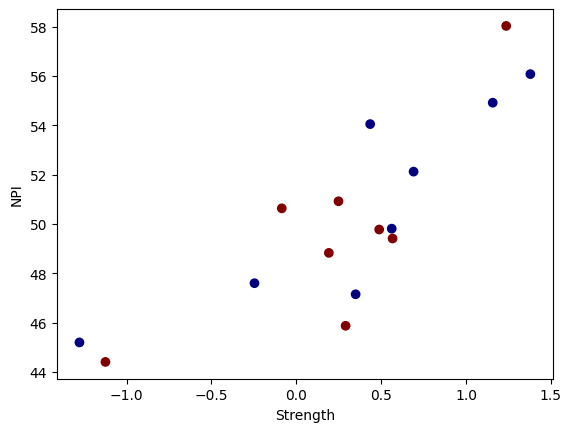

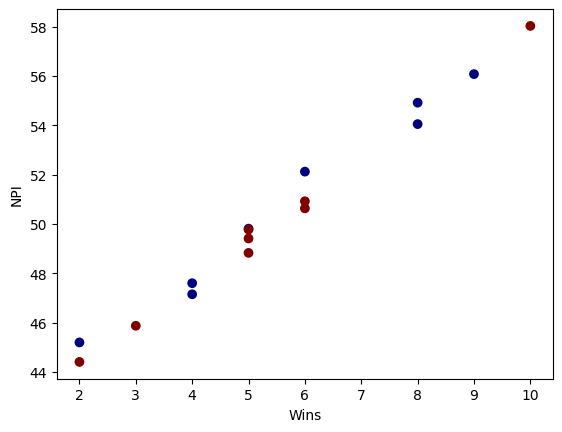

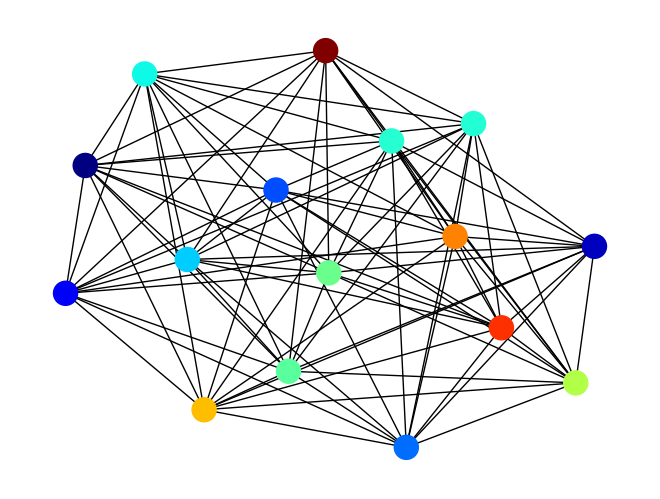

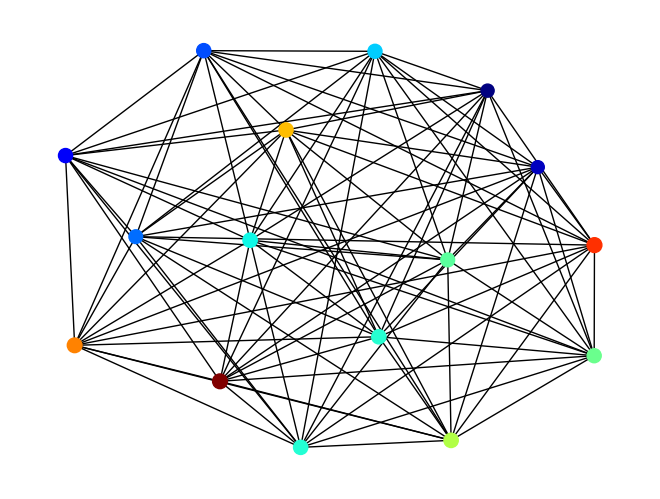

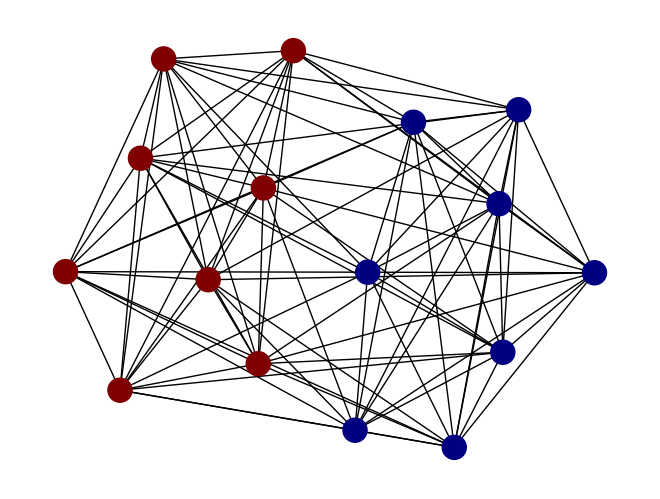

In [9]:
plt.scatter(strength,npi,c=conf,cmap='jet')
plt.xlabel('Strength')
plt.ylabel('NPI')
plt.show()

plt.scatter(wins,npi,c=conf,cmap='jet')
plt.xlabel('Wins')
plt.ylabel('NPI')
plt.show()

cws_net = nx.Graph()

for row in games:
    cws_net.add_edge(row[0],row[1])

for node in range(len(teams)):

    cws_net.nodes()[node]['CONF'] = conf[node]
    cws_net.nodes()[node]['WINS'] = wins[node]
    cws_net.nodes()[node]['NPI'] = npi[node]
    cws_net.nodes()[node]['S'] = strength[node]

kk_layout = nx.kamada_kawai_layout(cws_net)
nx.draw(cws_net,node_color=[cws_net.nodes()[node]['NPI'] for node in cws_net.nodes()],cmap='jet')
plt.show()
nx.draw(cws_net,node_color=[cws_net.nodes()[node]['NPI'] for node in cws_net.nodes()],node_size=[10*(10+cws_net.nodes()[node]['S']) for node in cws_net.nodes()],cmap='jet')
plt.show()
nx.draw(cws_net,node_color=[cws_net.nodes()[node]['CONF'] for node in cws_net.nodes()],cmap='jet')
plt.show()